[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ChrisW09/Quantitative-Research-Methods/blob/main/Lab_Notebooks/chapter_00b_lab.ipynb)

*This notebook runs on Colab as-is. The badge link above and the `GITHUB_RAW` line in the setup cell already point to this repository, so everything installs and loads automatically.*

# Chapter 0b — Precourse Toolkit
## Lab: notation, logs and odds, likelihood, and the Python the labs use

**Course:** Quantitative Research Methods
**Instructor:** Prof. Dr. Christoph Weisser, HSBI
**Source:** James, Witten, Hastie, Tibshirani & Taylor (2023), *An Introduction to Statistical Learning, with Applications in Python*, Springer. Companion code at [statlearning.com](https://www.statlearning.com).

**Goal of this lab.** The second half of the precourse, in code. Part (a) refreshed the statistics; this notebook covers the *machinery* the later chapters use without explanation:

1. reading mathematical notation — sums, products, `argmin`, indicators, sets;
2. logs and exponentials, and what a logged coefficient means;
3. probability → odds → log-odds → back, and why classification lives on the logit scale;
4. likelihood and maximum likelihood, by hand and numerically;
5. counting: why $2^p$ ends best-subset selection;
6. the Python patterns every lab uses — functions, loops, seeds, `fit`/`predict`, and the split discipline.

**Companion slides:** `Lecture_Slides/chapter_00b/chapter_00b.pdf`.

## Setup

Run this cell once. The `ISLP` package can be installed with `pip install ISLP`; the same data are also in the workspace's `ALL CSV FILES - 2nd Edition` folder.

In [1]:
# --- Setup: runs locally AND on Google Colab --------------------------------
import warnings; warnings.filterwarnings('ignore')  # keep output clean; remove to see all warnings
import importlib.util, os, subprocess, sys

IN_COLAB = 'google.colab' in sys.modules

def _ensure(pkg, import_name=None):
    """pip-install pkg (quietly) if its import is missing."""
    if importlib.util.find_spec(import_name or pkg) is None:
        subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', pkg], check=False)

if IN_COLAB:  # Colab ships numpy/pandas/sklearn/statsmodels; add course extras
    for _pkg, _imp in [('ISLP', 'ISLP')]:
        _ensure(_pkg, _imp)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

rng = np.random.default_rng(2024)
plt.rcParams['figure.dpi'] = 110

try:
    from ISLP import load_data
    HAVE_ISLP = True
except ImportError:
    HAVE_ISLP = False
    print('ISLP not installed; using CSV / URL fallbacks.')

# Local CSV location (repo layout first, then legacy paths, then a data/ cache).
_CANDIDATES = ['../ALL CSV FILES - 2nd Edition',
               'ALL CSV FILES - 2nd Edition',
               '../../ALL CSV FILES - 2nd Edition', 'data']
CSV = next((p for p in _CANDIDATES if os.path.isdir(p)), 'data')

# GITHUB_RAW lets a fresh Colab runtime fetch any
# CSV that is neither in ISLP nor already local (spaces in the folder -> %20).
GITHUB_RAW = ('https://raw.githubusercontent.com/ChrisW09/Quantitative-Research-Methods/main/'
              'ALL%20CSV%20FILES%20-%202nd%20Edition')

# The three datasets NOT in the ISLP package -> load from the book's official
# site so the notebook works on a fresh Colab even before the repo is published.
KNOWN_URLS = {
    'Advertising': 'https://www.statlearning.com/s/Advertising.csv',
    'Heart':       'https://www.statlearning.com/s/Heart.csv',
    'Income1':     'https://www.statlearning.com/s/Income1.csv',
    'Income2':     'https://www.statlearning.com/s/Income2.csv',
}

def load(name, **read_csv_kwargs):
    """Load a course dataset. Order: ISLP package -> R datasets -> local CSV
    -> official book URL -> your GitHub repo. Works locally and on Colab."""
    if HAVE_ISLP:
        try:
            return load_data(name)
        except Exception:
            pass
    if name == 'USArrests':                       # classic R dataset, not in ISLP
        try:
            import statsmodels.api as sm
            return sm.datasets.get_rdataset('USArrests', 'datasets').data
        except Exception:
            pass
    path = f'{CSV}/{name}.csv'
    if os.path.exists(path):                      # running from the repo (local)
        return pd.read_csv(path, **read_csv_kwargs)
    remotes = ([KNOWN_URLS[name]] if name in KNOWN_URLS else []) + [f'{GITHUB_RAW}/{name}.csv']
    for url in remotes:                           # fresh Colab: stream over https
        try:
            return pd.read_csv(url, **read_csv_kwargs)
        except Exception:
            continue
    raise FileNotFoundError(
        f"Could not load {name!r}. Put the CSV in '{CSV}/' or check your connection for the GITHUB_RAW fallback.")

ISLP not installed; using CSV / URL fallbacks.


In [2]:
from scipy import stats, optimize
import statsmodels.api as sm
import statsmodels.formula.api as smf

ACCENT, ORANGE, GREY, GREEN = '#26468C', '#C8641E', '#7A7A7A', '#2E7D5B'
print('ready')

ready


## 1. Reading mathematical notation

Every symbol below is an instruction. Translating it into one line of numpy is the fastest way to make it stop being intimidating.

In [3]:
y     = np.array([3.0, 1.0, 4.0])
y_hat = np.array([2.0, 2.0, 4.0])

# sum_i (y_i - yhat_i)^2  -- "for each observation, square the gap, add them up"
print('RSS          ', ((y - y_hat) ** 2).sum())          # 2.0
# prod_i y_i
print('product      ', y.prod())                          # 12.0
# (1/n) sum_i I(y_i != yhat_i)   -- the indicator is just a boolean, averaged
print('error rate   ', (y != y_hat).mean().round(3))      # 0.667
# S = {i : y_i > 2};  |S| and the mean over S
S = y > 2
print('|S| and mean ', S.sum(), y[S].mean())              # 2, 3.5

RSS           2.0
product       12.0
error rate    0.667
|S| and mean  2 3.5


**Booleans are indicators.** `y != y_hat` is a vector of `True`/`False`; averaging it gives the proportion of `True` — exactly $\frac{1}{n}\sum_i I(y_i \ne \hat y_i)$. That single fact makes most classification formulas one-liners.

In [4]:
# min vs argmin: a value versus the input that achieves it
theta = np.linspace(0, 8, 801)
f = (theta - 3) ** 2 + 5
print(f'min f      = {f.min():.2f}      <- the VALUE')
print(f'argmin f   = {theta[f.argmin()]:.2f}      <- the PARAMETER')

# np.argmin returns a POSITION, not the value at it -- the classic lab bug
scores = [4.9, 4.4, 4.4, 4.5, 4.9]
print(f'\nargmin position {np.argmin(scores)}  ->  degree {np.argmin(scores) + 1}')

min f      = 5.00      <- the VALUE
argmin f   = 3.00      <- the PARAMETER

argmin position 1  ->  degree 2


## 2. Logs and exponentials

`np.log` is the *natural* log (base $e$), the inverse of `np.exp`. The three rules that matter: $\log(ab)=\log a+\log b$, $\log(a/b)=\log a-\log b$, $\log(a^k)=k\log a$.

In [5]:
a, b = 2.0, 4.0
print(np.log(a * b), '=', np.log(a) + np.log(b))       # multiplication -> addition
print(np.log(a ** 5), '=', 5 * np.log(a))              # powers -> multiplication
print(np.exp(np.log(7.0)), np.log(np.exp(7.0)))        # they undo each other

# Solve e^{0.4 t} = 5   ->   t = log(5)/0.4
print('\nt =', round(np.log(5) / 0.4, 3))

2.0794415416798357 = 2.0794415416798357
3.4657359027997265 = 3.4657359027997265
6.999999999999999 7.0

t = 4.024


In [6]:
# Why we work with log-likelihoods: a product of 1000 probabilities underflows.
p = np.full(1000, 0.5)
print('product      :', p.prod())                       # 0.0  -- underflow!
print('sum of logs  :', np.log(p).sum().round(2))       # -693.15 -- fine
print('back via exp :', np.exp(np.log(p).sum()))        # still 0.0, as expected

product      : 9.332636185032189e-302
sum of logs  : -693.15
back via exp : 9.332636185031767e-302


### A log scale can straighten a relationship

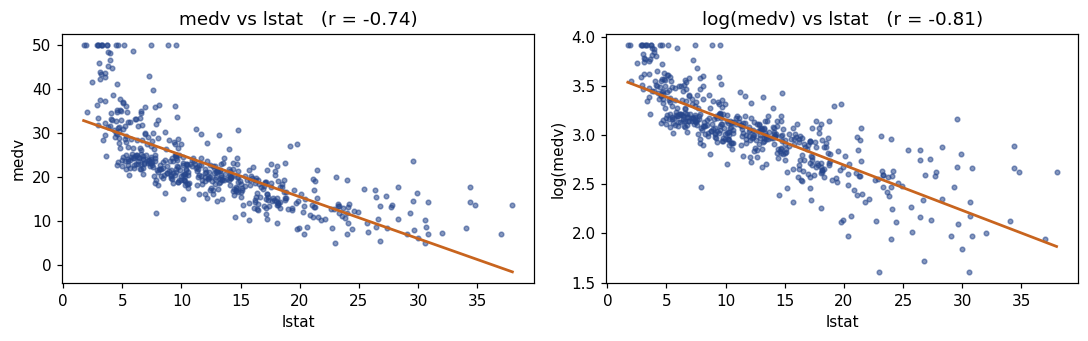

In [7]:
Boston = load('Boston')
x, yv = Boston['lstat'], Boston['medv']

fig, axes = plt.subplots(1, 2, figsize=(10, 3.2))
for ax, target, lab in [(axes[0], yv, 'medv'), (axes[1], np.log(yv), 'log(medv)')]:
    ax.scatter(x, target, s=9, color=ACCENT, alpha=.55)
    b1, b0 = np.polyfit(x, target, 1)
    xs = np.linspace(x.min(), x.max(), 50)
    ax.plot(xs, b0 + b1 * xs, color=ORANGE, lw=1.8)
    ax.set_title(f'{lab} vs lstat   (r = {np.corrcoef(x, target)[0,1]:.2f})')
    ax.set_xlabel('lstat'); ax.set_ylabel(lab)
plt.tight_layout(); plt.show()

In [8]:
# Interpreting a coefficient on a logged response: multiply by e^beta.
fit_log = smf.ols('np.log(medv) ~ lstat', data=Boston).fit()
b = fit_log.params['lstat']
print(f'coefficient on lstat        : {b:.4f}')
print(f'multiplicative effect e^b   : {np.exp(b):.4f}')
print(f'i.e. a 1-point rise in lstat is associated with {100*(np.exp(b)-1):+.2f}% in medv')
print(f'the naive "100*b%" shortcut : {100*b:+.2f}%   (close, because b is small)')

coefficient on lstat        : -0.0461
multiplicative effect e^b   : 0.9550
i.e. a 1-point rise in lstat is associated with -4.50% in medv
the naive "100*b%" shortcut : -4.61%   (close, because b is small)


## 3. Probability, odds and the logit

$\text{odds} = p/(1-p)$, $\text{logit}(p) = \log \text{odds}$, and the way back is the logistic (sigmoid) function $\sigma(z) = 1/(1+e^{-z})$.

In [9]:
def odds(p):   return p / (1 - p)
def logit(p):  return np.log(odds(p))
def sigmoid(z): return 1 / (1 + np.exp(-np.clip(z, -35, 35)))   # clipped = safe

tab = pd.DataFrame({'p': [0.10, 0.25, 0.50, 0.75, 0.90]})
tab['odds'] = odds(tab.p).round(3)
tab['log-odds'] = logit(tab.p).round(3)
tab['back to p'] = sigmoid(logit(tab.p)).round(3)
tab

,p,odds,log-odds,back to p
0,0.10,0.111,-2.197,0.10
1,0.25,0.333,-1.099,0.25
2,0.50,1.000,0.000,0.50
3,0.75,3.000,1.099,0.75
4,0.90,9.000,2.197,0.90


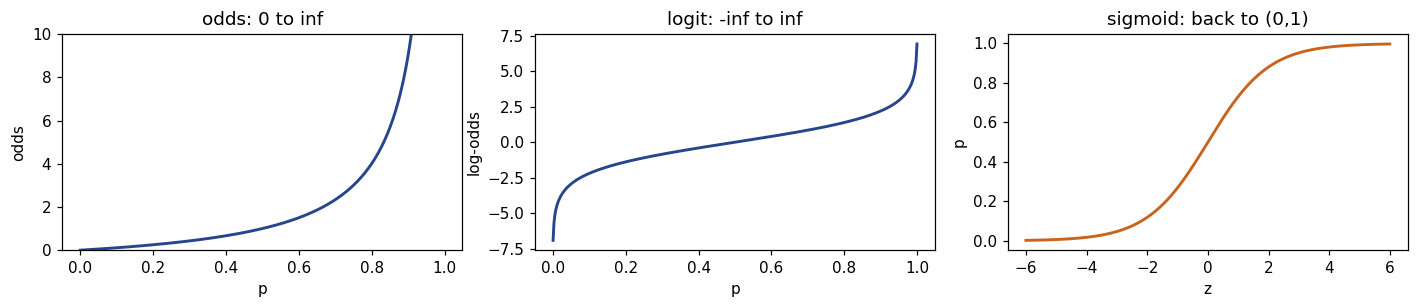

In [10]:
p = np.linspace(.001, .999, 400); z = np.linspace(-6, 6, 400)
fig, axes = plt.subplots(1, 3, figsize=(13, 2.9))
axes[0].plot(p, odds(p), color=ACCENT, lw=1.9); axes[0].set_ylim(0, 10)
axes[0].set_xlabel('p'); axes[0].set_ylabel('odds'); axes[0].set_title('odds: 0 to inf')
axes[1].plot(p, logit(p), color=ACCENT, lw=1.9)
axes[1].set_xlabel('p'); axes[1].set_ylabel('log-odds'); axes[1].set_title('logit: -inf to inf')
axes[2].plot(z, sigmoid(z), color=ORANGE, lw=1.9)
axes[2].set_xlabel('z'); axes[2].set_ylabel('p'); axes[2].set_title('sigmoid: back to (0,1)')
plt.tight_layout(); plt.show()

### Why a straight line cannot model a probability

n = 10000,  default rate = 0.0333


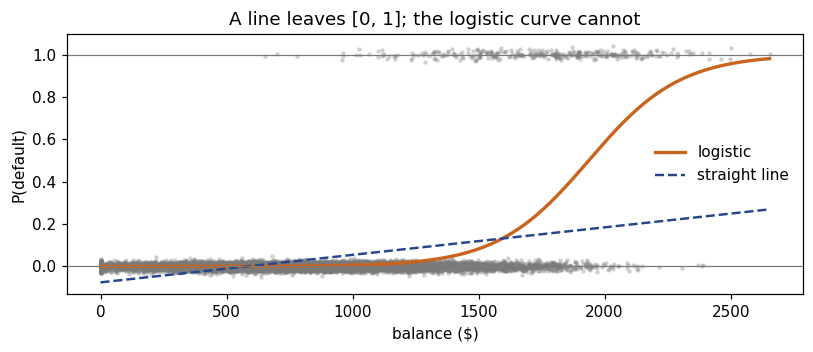


fitted log-odds = -10.651 + 0.00550 * balance
odds ratio per $100 of balance: 1.733


In [11]:
Default = load('Default')
xb = Default['balance'].to_numpy()
yb = (Default['default'] == 'Yes').astype(float).to_numpy()
print(f'n = {len(yb)},  default rate = {yb.mean():.4f}')

logit_fit = sm.Logit(yb, sm.add_constant(xb)).fit(disp=0)
lin_b1, lin_b0 = np.polyfit(xb, yb, 1)
grid = np.linspace(xb.min(), xb.max(), 300)

fig, ax = plt.subplots(figsize=(7.5, 3.3))
ax.scatter(xb, yb + rng.normal(0, .012, len(yb)), s=4, color=GREY, alpha=.25)
ax.plot(grid, sigmoid(logit_fit.params[0] + logit_fit.params[1] * grid),
        color=ORANGE, lw=2.2, label='logistic')
ax.plot(grid, lin_b0 + lin_b1 * grid, color=ACCENT, lw=1.6, ls='--', label='straight line')
ax.axhline(0, color=GREY, lw=.8); ax.axhline(1, color=GREY, lw=.8)
ax.set_xlabel('balance ($)'); ax.set_ylabel('P(default)'); ax.legend(frameon=False)
ax.set_title('A line leaves [0, 1]; the logistic curve cannot')
plt.tight_layout(); plt.show()

print(f'\nfitted log-odds = {logit_fit.params[0]:.3f} + {logit_fit.params[1]:.5f} * balance')
print(f'odds ratio per $100 of balance: {np.exp(100*logit_fit.params[1]):.3f}')

The published ISLP fit is $-10.65 + 0.0055\times\text{balance}$ — reproduced exactly above. A coefficient of $0.0055$ on the log-odds scale means each extra \$100 of balance multiplies the **odds** of default by $e^{100(0.0055)} = 1.73$.

## 4. Likelihood and maximum likelihood

The likelihood is the probability of the data you *did* observe, read as a function of the parameter. Maximum likelihood picks the parameter that makes the observed data most probable.

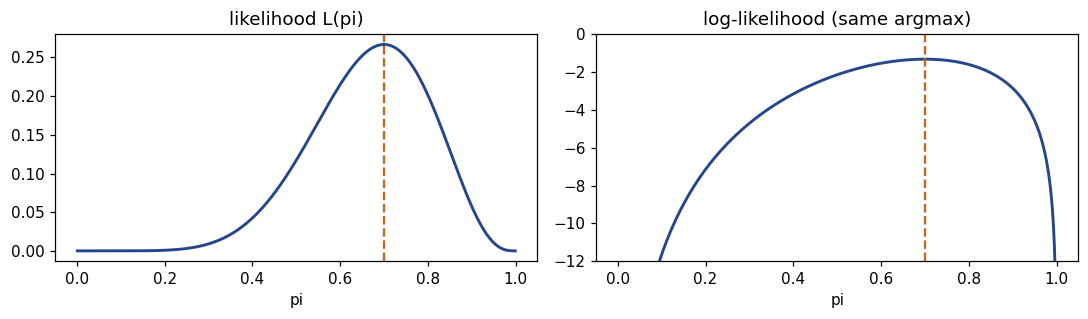

argmax of L  : 0.699
argmax of ll : 0.699  <- identical, as log is increasing
closed form  : k/n = 0.7


In [12]:
# A coin: 7 heads in 10 tosses.
n, k = 10, 7
pi = np.linspace(.001, .999, 500)
L = stats.binom.pmf(k, n, pi)
ll = np.log(L)

fig, axes = plt.subplots(1, 2, figsize=(10, 3))
axes[0].plot(pi, L, color=ACCENT, lw=1.9); axes[0].axvline(k/n, color=ORANGE, ls='--')
axes[0].set_title('likelihood L(pi)'); axes[0].set_xlabel('pi')
axes[1].plot(pi, ll, color=ACCENT, lw=1.9); axes[1].axvline(k/n, color=ORANGE, ls='--')
axes[1].set_ylim(-12, 0); axes[1].set_title('log-likelihood (same argmax)'); axes[1].set_xlabel('pi')
plt.tight_layout(); plt.show()

print('argmax of L  :', round(pi[L.argmax()], 3))
print('argmax of ll :', round(pi[ll.argmax()], 3), ' <- identical, as log is increasing')
print('closed form  : k/n =', k/n)

In [13]:
# The Bernoulli MLE on real data (Extended Exercise 0b.1)
k_def, n_def = int(yb.sum()), len(yb)
print(f'{k_def} defaults out of {n_def}  ->  pi_hat = k/n = {k_def/n_def:.4f}')

# ...and the same answer found numerically, by maximising the log-likelihood
def neg_loglik(pi):
    return -(k_def * np.log(pi) + (n_def - k_def) * np.log(1 - pi))

opt = optimize.minimize_scalar(neg_loglik, bounds=(1e-6, 1-1e-6), method='bounded')
print(f'numerical maximiser        = {opt.x:.4f}')

333 defaults out of 10000  ->  pi_hat = k/n = 0.0333
numerical maximiser        = 0.0333


### Least squares *is* maximum likelihood under normal errors

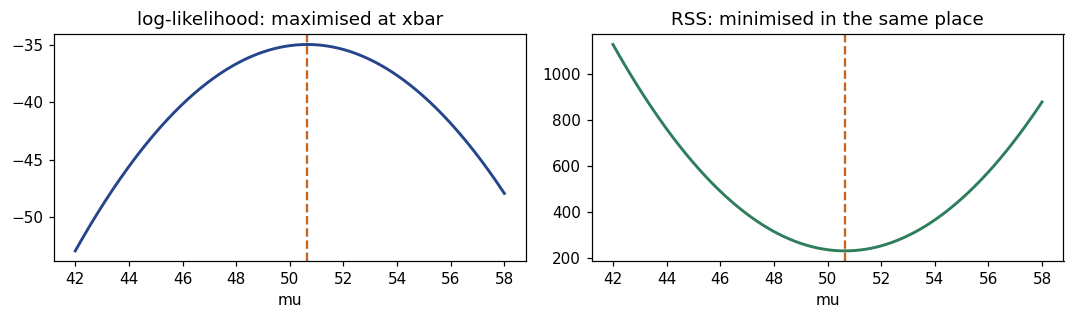

argmax loglik : 50.662
argmin RSS    : 50.662
sample mean   : 50.651


In [14]:
data = rng.normal(50, 5, 12)
mus = np.linspace(42, 58, 400)
loglik = np.array([stats.norm.logpdf(data, m, 5).sum() for m in mus])
rss    = np.array([((data - m) ** 2).sum() for m in mus])

fig, axes = plt.subplots(1, 2, figsize=(10, 3))
axes[0].plot(mus, loglik, color=ACCENT, lw=1.9); axes[0].axvline(data.mean(), color=ORANGE, ls='--')
axes[0].set_title('log-likelihood: maximised at xbar'); axes[0].set_xlabel('mu')
axes[1].plot(mus, rss, color=GREEN, lw=1.9); axes[1].axvline(data.mean(), color=ORANGE, ls='--')
axes[1].set_title('RSS: minimised in the same place'); axes[1].set_xlabel('mu')
plt.tight_layout(); plt.show()

print('argmax loglik :', round(mus[loglik.argmax()], 3))
print('argmin RSS    :', round(mus[rss.argmin()], 3))
print('sample mean   :', round(data.mean(), 3))

In [15]:
# The logistic log-likelihood, maximised by hand -- this IS Chapter 4's fitting.
X = np.column_stack([np.ones_like(xb), (xb - xb.mean()) / xb.std()])

def neg_ll(beta):
    p_ = sigmoid(X @ beta)
    return -(yb * np.log(p_ + 1e-12) + (1 - yb) * np.log(1 - p_ + 1e-12)).sum()

res = optimize.minimize(neg_ll, np.zeros(2))
print('our optimiser :', res.x.round(4))
print('statsmodels   :', sm.Logit(yb, X).fit(disp=0).params.round(4))
print('\nNote: -log-likelihood is exactly the "binary cross-entropy" of Chapter 10.')

our optimiser : [-6.0577  2.6598]
statsmodels   : [-6.0577  2.6598]

Note: -log-likelihood is exactly the "binary cross-entropy" of Chapter 10.


## 5. Counting: why best-subset selection dies

In [16]:
from math import comb, factorial
p_ = 6
print(f'models with exactly 2 of {p_} predictors : {comb(p_, 2)}')
print(f'all subsets 2^p                        : {2**p_}')
print(f'forward stepwise 1 + p(p+1)/2          : {1 + p_*(p_+1)//2}')

print('\n  p     best subset        stepwise      time @0.01s/fit (best subset)')
for pp in (6, 10, 20, 30, 40):
    full, step = 2**pp, 1 + pp*(pp+1)//2
    secs = full * 0.01
    when = (f'{secs:,.1f} s' if secs < 3600
            else f'{secs/3600:,.1f} hours' if secs < 86400
            else f'{secs/86400:,.0f} days')
    print(f'{pp:3d}  {full:>15,}  {step:>10,}   {when:>18}')

models with exactly 2 of 6 predictors : 15
all subsets 2^p                        : 64
forward stepwise 1 + p(p+1)/2          : 22

  p     best subset        stepwise      time @0.01s/fit (best subset)
  6               64          22                0.6 s
 10            1,024          56               10.2 s
 20        1,048,576         211            2.9 hours
 30    1,073,741,824         466             124 days
 40  1,099,511,627,776         821         127,258 days


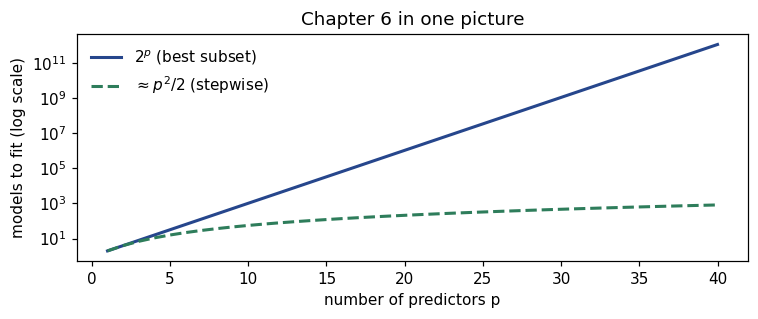

In [17]:
ps = np.arange(1, 41)
fig, ax = plt.subplots(figsize=(7, 3))
ax.semilogy(ps, 2.0**ps, color=ACCENT, lw=2, label='$2^p$ (best subset)')
ax.semilogy(ps, ps*(ps+1)/2 + 1, color=GREEN, lw=2, ls='--', label='$\\approx p^2/2$ (stepwise)')
ax.set_xlabel('number of predictors p'); ax.set_ylabel('models to fit (log scale)')
ax.legend(frameon=False); ax.set_title('Chapter 6 in one picture')
plt.tight_layout(); plt.show()

## 6. The Python patterns every lab uses

A function, a loop, a seed, and `fit`/`predict` on a split. That is the skeleton of all fourteen labs.

In [18]:
def rmse(y_true, y_pred):
    """Root mean squared error."""
    return float(np.sqrt(np.mean((y_true - y_pred) ** 2)))

print(rmse(np.array([1., 2., 3.]), np.array([1., 2., 4.])))   # 0.577

0.5773502691896257


In [19]:
# Four idioms, one cell.
print([d**2 for d in range(5)])                      # list comprehension

Wage = load('Wage')
mask = Wage['age'] > 60                              # boolean mask
print('mean wage over 60:', Wage.loc[mask, 'wage'].mean().round(2))

for name, grp in list(Wage.groupby('education'))[:2]:   # iterate groups
    print(f'{name:<22} median wage {grp["wage"].median():.1f}')

for label, value in zip(['a', 'b'], [1, 2]):            # zip pairs things up
    print(label, value)

[0, 1, 4, 9, 16]
mean wage over 60: 112.76
1. < HS Grad           median wage 81.3
2. HS Grad             median wage 94.1
a 1
b 2


### The honest experiment: split, fit, score

This is Extended Exercise 0b.2, run for real on `Auto`.

In [20]:
from sklearn.model_selection import train_test_split

Auto = load('Auto')
Auto = Auto[pd.to_numeric(Auto['horsepower'], errors='coerce').notna()].copy()
Auto['horsepower'] = Auto['horsepower'].astype(float)
print('n after dropping missing horsepower:', len(Auto))

X_tr, X_te, y_tr, y_te = train_test_split(
    Auto['horsepower'].to_numpy(), Auto['mpg'].to_numpy(),
    test_size=0.3, random_state=42)          # <- the seed makes this reproducible

rows = []
for degree in range(1, 6):
    coef = np.polyfit(X_tr, y_tr, degree)
    rows.append({'degree': degree,
                 'train RMSE': rmse(y_tr, np.polyval(coef, X_tr)),
                 'test RMSE':  rmse(y_te, np.polyval(coef, X_te))})
res_tab = pd.DataFrame(rows).round(3)
print(res_tab.to_string(index=False))
print(f"\nbest degree on TEST error: {res_tab.loc[res_tab['test RMSE'].idxmin(), 'degree']}")

n after dropping missing horsepower: 392
 degree  train RMSE  test RMSE
      1       4.892      4.955
      2       4.311      4.522
      3       4.300      4.538
      4       4.300      4.545
      5       4.266      4.442

best degree on TEST error: 5


Read the two columns against each other. The training error falls monotonically — a more flexible curve always fits the data it already saw. The test error drops sharply from degree 1 to degree 2 and then goes flat: **the curvature is real, everything after it is noise.** Only the second column is evidence.

Notice what the table does *not* license: degree 5 has the lowest test RMSE here, but it beats degree 2 by 0.08, which is smaller than the variation between splits. The next two cells show why that matters.

In [21]:
# Why one split is not enough: repeat with 30 different seeds.
winners = []
for seed in range(30):
    a, b_, c, d = train_test_split(Auto['horsepower'].to_numpy(), Auto['mpg'].to_numpy(),
                                   test_size=0.3, random_state=seed)
    errs = [rmse(d, np.polyval(np.polyfit(a, c, deg), b_)) for deg in range(1, 6)]
    winners.append(int(np.argmin(errs)) + 1)

print('winning degree across 30 splits:', pd.Series(winners).value_counts().sort_index().to_dict())
print('\nA single split picks a winner partly by luck -- which is why Chapter 5')
print('replaces it with k-fold cross-validation.')

winning degree across 30 splits: {2: 6, 3: 3, 5: 21}

A single split picks a winner partly by luck -- which is why Chapter 5
replaces it with k-fold cross-validation.


In [22]:
# Cross-validation: average over splits instead of trusting one.
from sklearn.model_selection import KFold

print('5-fold CV RMSE by degree, repeated 10x with different shuffles:\n')
for deg in range(1, 7):
    per_repeat = []
    for rep in range(10):
        kf = KFold(5, shuffle=True, random_state=rep)
        folds = [rmse(Auto['mpg'].to_numpy()[te],
                      np.polyval(np.polyfit(Auto['horsepower'].to_numpy()[tr],
                                            Auto['mpg'].to_numpy()[tr], deg),
                                 Auto['horsepower'].to_numpy()[te]))
                 for tr, te in kf.split(Auto)]
        per_repeat.append(np.mean(folds))
    print(f'  degree {deg}: {np.mean(per_repeat):.3f}   '
          f'(spread across repeats +-{np.std(per_repeat):.3f})')

5-fold CV RMSE by degree, repeated 10x with different shuffles:

  degree 1: 4.908   (spread across repeats +-0.011)
  degree 2: 4.363   (spread across repeats +-0.016)
  degree 3: 4.371   (spread across repeats +-0.021)
  degree 4: 4.383   (spread across repeats +-0.035)
  degree 5: 4.341   (spread across repeats +-0.035)
  degree 6: 4.343   (spread across repeats +-0.039)


The verdict: degree 1 is clearly worse (4.91); degrees 2–6 all land between 4.34 and 4.38, a gap no larger than the spread between repeats. So the honest conclusion is **"a quadratic is a real improvement on a line; beyond that this data set cannot tell"** — and the right response to an ambiguous winner is to prefer the simpler model, not to hunt for a seed that favours the complex one. Chapter 5 makes this procedure standard.

In [23]:
# The scikit-learn contract, on the same data.
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

model = LinearRegression().fit(X_tr.reshape(-1, 1), y_tr)      # 1-2. choose + fit
pred = model.predict(X_te.reshape(-1, 1))                      # 3. predict
print('slope', round(float(model.coef_[0]), 4),
      '| intercept', round(float(model.intercept_), 3),
      '| test RMSE', round(mean_squared_error(y_te, pred) ** .5, 3))
print('\nfit / predict / score -- identical for every model in this course.')

slope -0.1663 | intercept 41.085 | test RMSE 4.955

fit / predict / score -- identical for every model in this course.


## Lecture exercises — worked Python solutions

The `[Python]`-tagged exercises of the Chapter 0b deck, solved in code.

### Exercise 0b.6 — Reading and fixing code *(slide: Exercise 0b.6 [Python])*

The student's loop tried degrees 1–4, printed `3` for the best degree, and scored every fit on the data it was trained on.

In [24]:
# The buggy version, reproduced -- note it "discovers" the most complex model.
scores_bad = []
for degree in range(1, 5):                       # (a) only degrees 1..4
    coef = np.polyfit(X_tr, y_tr, degree)
    scores_bad.append(rmse(y_tr, np.polyval(coef, X_tr)))   # (b) scored on TRAINING data
print('training RMSE by degree :', np.round(scores_bad, 3))
print('argmin position          :', np.argmin(scores_bad),
      ' -> degree', np.argmin(scores_bad) + 1, '(position != degree!)')

# The honest version
scores_ok = [rmse(y_te, np.polyval(np.polyfit(X_tr, y_tr, d), X_te)) for d in range(1, 6)]
print('\ntest RMSE by degree      :', np.round(scores_ok, 3))
print('best degree              :', int(np.argmin(scores_ok)) + 1)

training RMSE by degree : [4.892 4.311 4.3   4.3  ]
argmin position          : 3  -> degree 4 (position != degree!)

test RMSE by degree      : [4.955 4.522 4.538 4.545 4.442]
best degree              : 5


### Exercise 0b.3 — Odds and odds ratios *(slide: [Math], verified here)*

In [25]:
p_vouch, p_none = 0.45, 0.25
o1, o0 = odds(p_vouch), odds(p_none)
print(f'odds with voucher {o1:.3f}, without {o0:.3f}')
print(f'odds ratio        {o1/o0:.3f}   vs risk ratio {p_vouch/p_none:.3f}  <- NOT the same')
print(f'log-odds difference {logit(p_vouch) - logit(p_none):.3f} = log(OR) {np.log(o1/o0):.3f}')
print(f'a logistic coefficient of 0.90 -> odds ratio {np.exp(0.90):.3f}')
print(f'log-odds of -1.4 -> probability {sigmoid(-1.4):.3f}')

odds with voucher 0.818, without 0.333
odds ratio        2.455   vs risk ratio 1.800  <- NOT the same
log-odds difference 0.898 = log(OR) 0.898
a logistic coefficient of 0.90 -> odds ratio 2.460
log-odds of -1.4 -> probability 0.198


### Exercise 0b.2 — Logs in practice *(slide: [Math], verified here)*

In [26]:
print('log(x^3 y) - log(y) == 3 log x :',
      np.isclose(np.log(2.0**3 * 5) - np.log(5), 3*np.log(2.0)))
print('solve e^{0.4t} = 5 -> t =', round(np.log(5)/0.4, 3))
print('wage model: e^0.08 =', round(np.exp(0.08), 4), '-> +8.3% per year of education')
print('3% growth: log(1.03) =', round(np.log(1.03), 4), '-> a straight line in t on a log scale')

log(x^3 y) - log(y) == 3 log x : True
solve e^{0.4t} = 5 -> t = 4.024
wage model: e^0.08 = 1.0833 -> +8.3% per year of education
3% growth: log(1.03) = 0.0296 -> a straight line in t on a log scale


## Exercises

1. **Notation.** For `y = [5, 2, 9, 1]` and `y_hat = [4, 3, 9, 2]`, compute the RSS, the error rate, and the mean of $\{y_i : y_i > 3\}$ — each in one line.
2. **Logs.** Fit `log(medv) ~ lstat + rm` on `Boston`. Convert both coefficients into percentage effects and say which predictor matters more.
3. **Odds.** In `Default`, compute the default rate for students and non-students, then the odds ratio. Fit `sm.Logit` with the student dummy and check that $e^{\beta}$ reproduces your odds ratio.
4. **Likelihood.** Write the Poisson log-likelihood $\ell(\lambda) = \sum_i (y_i\log\lambda - \lambda)$ + const for a small count vector, maximise it numerically, and check the answer against $\bar y$.
5. **Counting.** For $p = 15$, compute the number of models of each size $k$, plot it, and say where the peak is and why.
6. **The experiment.** Repeat the `Auto` degree comparison using 5-fold cross-validation (`sklearn.model_selection.cross_val_score`) instead of one split. Does the winning degree become more stable?
7. **Leakage.** Standardise `horsepower` using the full data set, then using only the training set. Compare the two test RMSEs and explain the difference.

## Where to go next

- **Slides:** `Lecture_Slides/chapter_00b/chapter_00b.pdf`.
- **Part (a):** `chapter_00_lab.ipynb` — the statistics refresher, if you have not done it.
- **Next lab:** `chapter_01_lab.ipynb` — the course proper begins.